In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.shape

(5000, 13)

In [5]:
df.isnull().sum()


Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df = df.drop_duplicates()

In [8]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [9]:
#(df["Physical_Activity_Hours"] < 0).sum()

In [10]:
#df.loc[df["Physical_Activity_Hours"] < 0, "Physical_Activity_Hours"]

In [11]:
#df = df[df["Physical_Activity_Hours"] >= 0]

In [12]:
#f.loc[df["Physical_Activity_Hours"] < 0, "Physical_Activity_Hours"]

# EDA 





<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

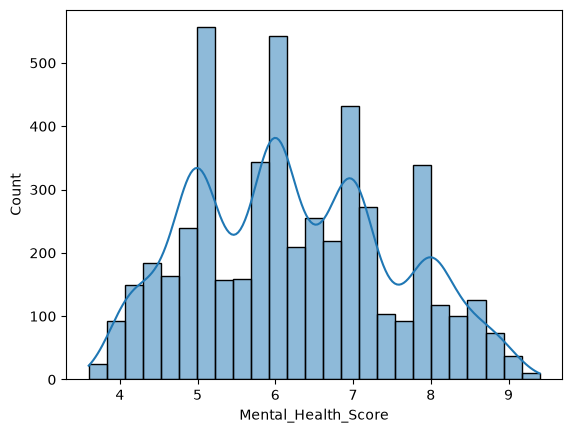

In [13]:
sns.histplot(df['Mental_Health_Score'],kde= True)

<Axes: >

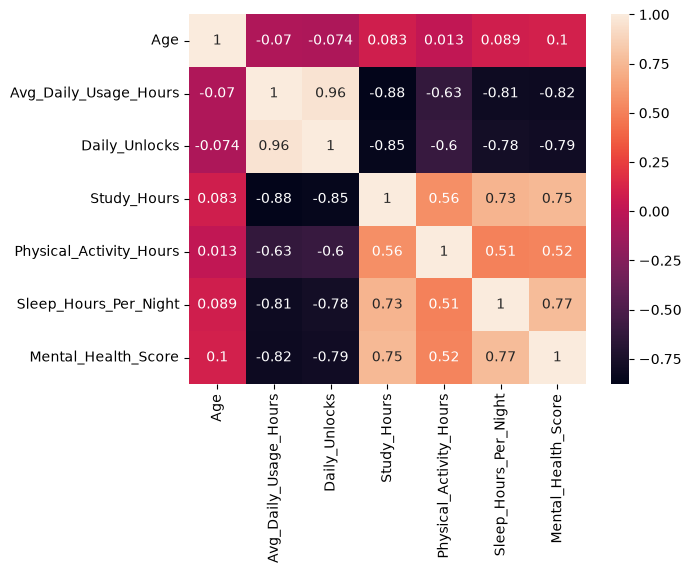

In [14]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [15]:
df['Stress_Level'].unique()

<StringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

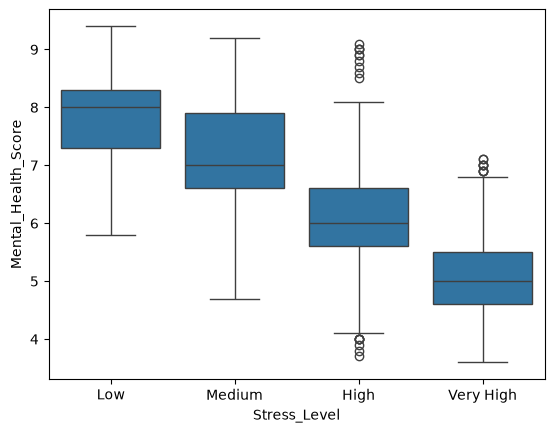

In [16]:
order=['Low','Medium','High','Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score',data=df ,order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

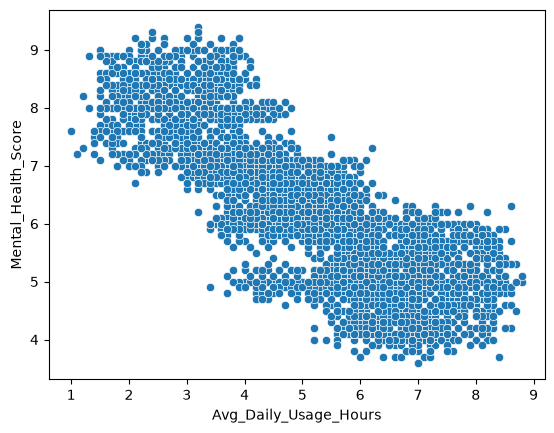

In [17]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

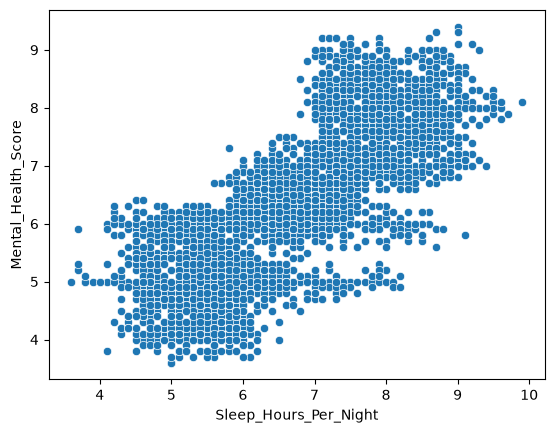

In [18]:
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Instagram'),
  Text(1, 0, 'TikTok'),
  Text(2, 0, 'Facebook'),
  Text(3, 0, 'LinkedIn'),
  Text(4, 0, 'YouTube'),
  Text(5, 0, 'Twitter'),
  Text(6, 0, 'Snapchat'),
  Text(7, 0, 'WhatsApp'),
  Text(8, 0, 'LINE'),
  Text(9, 0, 'VKontakte'),
  Text(10, 0, 'KakaoTalk'),
  Text(11, 0, 'WeChat')])

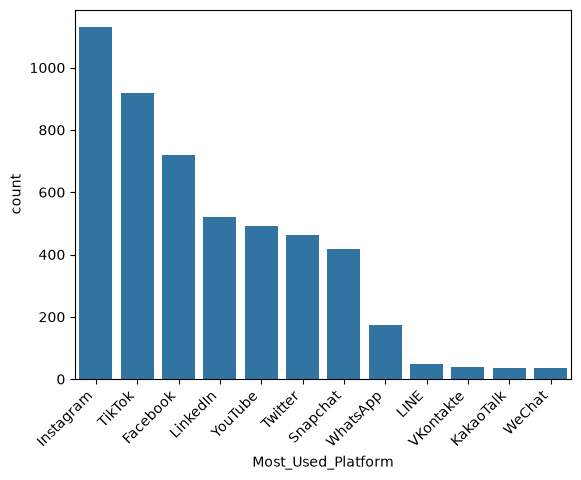

In [19]:
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation=45,ha='right')

# checking outliers

In [20]:
num_features=df.select_dtypes(include='number')
Q1=num_features.quantile(0.25)
Q3=num_features.quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)

outliers=(num_features<lower_bound) | (num_features>upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [21]:
df=df.drop_duplicates()

In [22]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [23]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [24]:
num_cols=df.select_dtypes(include='number')
num_cols.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

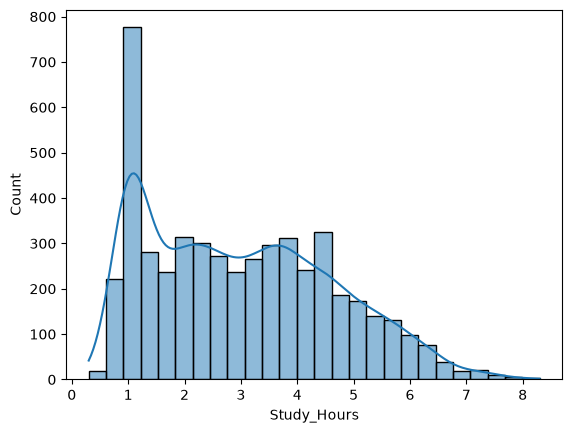

0.4361245948820438


In [25]:
sns.histplot(df['Study_Hours'], kde=True)
plt.show()

print(df['Study_Hours'].skew())

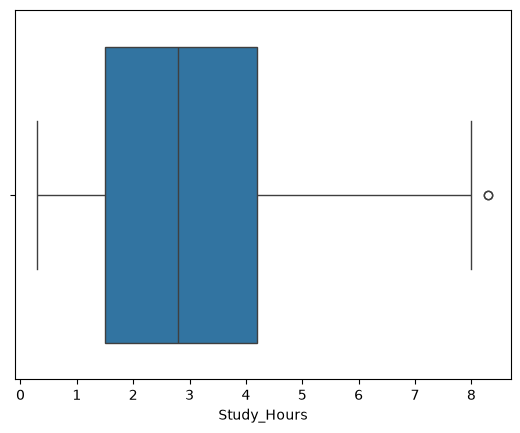

In [26]:
sns.boxplot(x=df['Study_Hours'])
plt.show()

In [27]:
#df['Study_Hours_log'] = np.log1p(df['Study_Hours'])
#print(df['Study_Hours_log'].skew())

In [33]:
top_countries=df['Country'].value_counts().index[:10].tolist()


In [43]:
def group_countries(Country):
 if Country in top_countries:
    return Country
 else:
    return 'Other'

In [44]:
df['grouped_countries'] = df['Country'].apply(group_countries)

In [45]:
df['grouped_countries'].value_counts()

grouped_countries
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64